In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import tqdm
import os
import wandb
from IPython.display import Image, display

In [8]:
# Hyperparameters
mb_size = 64
Z_dim = 100
h_dim = 128
lr = 2e-4 
wandb_log = True

X_dim = 784  # 28 x 28
epochs_gan = 1000
epochs_cnn = 50
wandb_log = True
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Load MNIST data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # Flatten the 28x28 image to 784
])

train_dataset_gan = datasets.MNIST(root='../MNIST', train=True, transform=transform, download=True)
train_loader_gan = DataLoader(train_dataset_gan, batch_size=mb_size, shuffle=True)

# Train/Val Split for the CNN Evaluation
train_size = 50000
val_size = 10000
cnn_train_set, cnn_val_set = random_split(train_dataset_gan, [train_size, val_size])

cnn_train_loader = DataLoader(cnn_train_set, batch_size=mb_size, shuffle=True)
cnn_val_loader = DataLoader(cnn_val_set, batch_size=mb_size, shuffle=False)
cnn_test_set = datasets.MNIST(root='../MNIST', train=False, transform=transform, download=True)
cnn_test_loader = DataLoader(cnn_test_set, batch_size=mb_size, shuffle=False)

os.makedirs('checkpoints', exist_ok=True)
os.makedirs('out_cGAN', exist_ok=True)

In [3]:
# Xavier Initialization
def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [4]:
# Generator
class Generator(nn.Module):
    def __init__(self, z_dim, h_dim, x_dim, num_classes=10, emb_dim=50):
        super(Generator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, emb_dim)
        self.fc1 = nn.Linear(z_dim + emb_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, x_dim)     
        self.apply(xavier_init)

    def forward(self, z, labels):
        c = self.label_emb(labels)
        x = torch.cat([z, c], dim=1)
        h = F.relu(self.fc1(x))
        out = torch.sigmoid(self.fc2(h))
        return out

In [5]:
# Discriminator
class Discriminator(nn.Module):
    def __init__(self, x_dim, h_dim, num_classes=10, emb_dim=50):
        super(Discriminator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, emb_dim)
        self.fc1 = nn.Linear(x_dim + emb_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, 1)
        self.apply(xavier_init)

    def forward(self, x, labels):
        c = self.label_emb(labels)
        x_combined = torch.cat([x, c], dim=1)
        h = F.relu(self.fc1(x_combined))
        out = torch.sigmoid(self.fc2(h))
        return out

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = x.view(-1, 1, 28, 28)
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

In [8]:
def evaluate_generator(G, Classifier, device, Z_dim, num_samples=100):
    G.eval()
    Classifier.eval()
    correct = 0
    with torch.no_grad():
        for target_digit in range(10):
            z = torch.randn(num_samples, Z_dim).to(device)
            labels = torch.full((num_samples,), target_digit, dtype=torch.long).to(device)
            fake_imgs = G(z, labels).view(num_samples, 1, 28, 28)
            
            outputs = Classifier(fake_imgs)
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == target_digit).sum().item()
            
    return (correct / (10 * num_samples)) * 100.0

In [9]:
def save_sample(G, epoch, mb_size, Z_dim, device, target_label=None):
    G.eval()
    with torch.no_grad():
        z = torch.randn(mb_size, Z_dim).to(device)
        if target_label is not None:
            labels = torch.full((mb_size,), target_label, dtype=torch.long).to(device)
        else:
            labels = torch.randint(0, 10, (mb_size,)).to(device)
        samples = G(z, labels).cpu().numpy()[:16]

    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)
    for i, sample in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis('off')
        ax.set_aspect('equal')
        plt.imshow(sample.reshape(28, 28), cmap='Greys_r')

    filename = f'{str(epoch).zfill(3)}_label_{target_label}.png' if target_label is not None else f'{str(epoch).zfill(3)}.png'
    plt.savefig(os.path.join("out_cGAN", filename), bbox_inches='tight')
    plt.close(fig)

--- Training the Evaluator CNN ---
CNN Epoch 1/50 | Train Loss: 0.2778 | Val Loss: 0.0922 | Val Acc: 97.29%
CNN Epoch 2/50 | Train Loss: 0.0804 | Val Loss: 0.0603 | Val Acc: 98.26%
CNN Epoch 3/50 | Train Loss: 0.0583 | Val Loss: 0.0557 | Val Acc: 98.37%
CNN Epoch 4/50 | Train Loss: 0.0471 | Val Loss: 0.0426 | Val Acc: 98.66%
CNN Epoch 5/50 | Train Loss: 0.0376 | Val Loss: 0.0416 | Val Acc: 98.85%
CNN Epoch 6/50 | Train Loss: 0.0338 | Val Loss: 0.0389 | Val Acc: 98.89%
CNN Epoch 7/50 | Train Loss: 0.0263 | Val Loss: 0.0401 | Val Acc: 98.89%
CNN Epoch 8/50 | Train Loss: 0.0241 | Val Loss: 0.0394 | Val Acc: 98.91%
CNN Epoch 9/50 | Train Loss: 0.0201 | Val Loss: 0.0442 | Val Acc: 98.68%
CNN Epoch 10/50 | Train Loss: 0.0175 | Val Loss: 0.0494 | Val Acc: 98.59%
CNN Epoch 11/50 | Train Loss: 0.0154 | Val Loss: 0.0496 | Val Acc: 98.85%
CNN Epoch 12/50 | Train Loss: 0.0147 | Val Loss: 0.0557 | Val Acc: 98.87%
CNN Epoch 13/50 | Train Loss: 0.0129 | Val Loss: 0.0453 | Val Acc: 98.88%
CNN Epoch 14

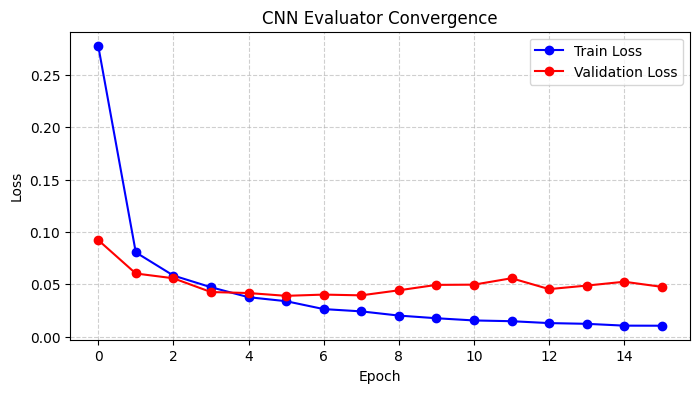


--- Testing the Evaluator CNN ---
 The Evaluator CNN is trained and locked With achieved Test Accuracy: 99.08%



In [9]:
print("--- Training the Evaluator CNN ---")
my_cnn = SimpleCNN().to(device)
cnn_optimizer = optim.Adam(my_cnn.parameters(), lr=1e-3)
cnn_loss_fn = nn.CrossEntropyLoss()

best_val_loss = float('inf')
patience = 10
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
for epoch in range(epochs_cnn):
    # Train
    my_cnn.train()
    train_loss = 0.0
    for X_batch, y_batch in cnn_train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        cnn_optimizer.zero_grad()
        loss = cnn_loss_fn(my_cnn(X_batch), y_batch)
        loss.backward()
        cnn_optimizer.step()
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(cnn_train_loader)
    
    # Validate
    my_cnn.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_val, y_val in cnn_val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            outputs = my_cnn(X_val)
            val_loss += cnn_loss_fn(outputs, y_val).item()
            _, predicted = torch.max(outputs, 1)
            total += y_val.size(0)
            correct += (predicted == y_val).sum().item()
            
    avg_val_loss = val_loss / len(cnn_val_loader)
    val_acc = 100.0 * correct / total
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)
    print(f"CNN Epoch {epoch+1}/{epochs_cnn} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(my_cnn.state_dict(), 'checkpoints/best_judge_cnn.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping CNN at Epoch {epoch+1}")
            break

# Locking the CNN weights
my_cnn.load_state_dict(torch.load('checkpoints/best_judge_cnn.pth', weights_only=True))
my_cnn.eval()
for param in my_cnn.parameters():
    param.requires_grad = False

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(history['train_loss'], label='Train Loss', color='blue', marker='o')
ax1.plot(history['val_loss'], label='Validation Loss', color='red', marker='o')
ax1.set_title('CNN Evaluator Convergence')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\n--- Testing the Evaluator CNN ---")
test_correct = 0
test_total = 0
with torch.no_grad():
    for X_test, y_test in cnn_test_loader:
        X_test, y_test = X_test.to(device), y_test.to(device)
        outputs = my_cnn(X_test)
        _, predicted = torch.max(outputs, 1)
        test_total += y_test.size(0)
        test_correct += (predicted == y_test).sum().item()

test_acc = 100.0 * test_correct / test_total
print(f" The Evaluator CNN is trained and locked With achieved Test Accuracy: {test_acc:.2f}%\n")

In [11]:
# Training
def cGANTraining(G, D, loss_fn, train_loader, device, Z_dim, G_solver, D_solver):
    G.train()
    D.train()

    D_loss_real_total = 0
    D_loss_fake_total = 0
    G_loss_total = 0
    t = tqdm.tqdm(train_loader, leave=False)
    
    for it, (X_real, labels) in enumerate(t):
        # Prepare real data
        X_real = X_real.float().to(device)
        labels = labels.to(device)
        
        # Setup targets
        b_size = X_real.size(0)
        z = torch.randn(b_size, Z_dim).to(device)
#        ones_label = torch.full((b_size, 1), 0.9).to(device)
        ones_label = torch.ones(b_size, 1).to(device)
        zeros_label = torch.zeros(b_size, 1).to(device)
        fake_labels = torch.randint(0, 10, (b_size,)).to(device)

        # ================= Train Discriminator =================
        G_sample = G(z, fake_labels)
        D_real = D(X_real, labels)
        D_fake = D(G_sample.detach(), fake_labels)

        D_loss_real = loss_fn(D_real, ones_label)
        D_loss_fake = loss_fn(D_fake, zeros_label)
        D_loss = D_loss_real + D_loss_fake
        
        D_loss_real_total += D_loss_real.item()
        D_loss_fake_total += D_loss_fake.item()

        D_solver.zero_grad()
        D_loss.backward()
        D_solver.step()

        # ================= Train Generator ====================
        z = torch.randn(b_size, Z_dim).to(device)
        fake_labels = torch.randint(0, 10, (b_size,)).to(device)
        G_sample = G(z, fake_labels)
        D_fake = D(G_sample, fake_labels)

        G_loss = loss_fn(D_fake, ones_label)
        G_loss_total += G_loss.item()

        G_solver.zero_grad()
        G_loss.backward()
        G_solver.step()

    # ================= Logging =================
    D_loss_real_avg = D_loss_real_total / len(train_loader)
    D_loss_fake_avg = D_loss_fake_total / len(train_loader)
    D_loss_avg = D_loss_real_avg + D_loss_fake_avg
    G_loss_avg = G_loss_total / len(train_loader)

    return G, D, G_loss_avg, D_loss_avg

In [12]:
########################### Main #######################################
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Instantiate models
G = Generator(Z_dim, h_dim, X_dim).to(device)
D = Discriminator(X_dim, h_dim).to(device)

# Optimizers
G_solver = optim.Adam(G.parameters(), lr)
D_solver = optim.Adam(D.parameters(), lr)

# Loss function
def my_bce_loss(preds, targets):
    return F.binary_cross_entropy(preds, targets)

#loss_fn = nn.BCEWithLogitsLoss()
loss_fn = my_bce_loss

if wandb_log: 
    wandb.login()
    wandb.init(project="conditional-gan-mnist")
    # Log hyperparameters
    wandb.config.update({
        "batch_size": mb_size,
        "Z_dim": Z_dim,
        "X_dim": X_dim,
        "h_dim": h_dim,
    })

best_gen_score = 0.0 
best_epoch = 0
save_dir = 'checkpoints'
os.makedirs(save_dir, exist_ok=True)

#Train epochs
epochs = 1000
print("Starting Training Loop")
for epoch in range(epochs):
    G, D, G_loss_avg, D_loss_avg= cGANTraining(G, D, loss_fn, train_loader_gan, device, Z_dim, G_solver, D_solver)
    gen_score = evaluate_generator(G, my_cnn, device, Z_dim)
    print(f'epoch{epoch}; D_loss: {D_loss_avg:.4f}; G_loss: {G_loss_avg:.4f}')
    if wandb_log:
        wandb.log({
            "D_loss": D_loss_avg,
            "G_loss": G_loss_avg,
            "CNN_Accuracy_Score": gen_score
        })
    if gen_score > best_gen_score:
        best_gen_score = gen_score
        best_epoch = epoch
        torch.save(G.state_dict(), 'checkpoints/G_absolute_best.pth')
        print("  --> Validation improved! Best model saved.")
        
    save_sample(G, epoch, mb_size, Z_dim, device)
    
torch.save(G.state_dict(), 'checkpoints/G_final_epoch100.pth')
print(f"\n CGAN Training Complete! The absolute best CNN Score ({best_gen_score:.2f}%) occurred at Epoch {best_epoch}.")

if wandb_log:
    wandb.run.summary["Best_Epoch"] = best_epoch
    wandb.run.summary["Best_CNN_Accuracy"] = best_gen_score
    wandb.finish()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: shravanikuchi (shravanikuchi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Starting Training Loop


epoch0; D_loss: 0.2959; G_loss: 2.7349
  --> Validation improved! Best model saved.


epoch1; D_loss: 0.2326; G_loss: 2.6274


epoch2; D_loss: 0.3237; G_loss: 2.1782
  --> Validation improved! Best model saved.


...

epoch996; D_loss: 0.3895; G_loss: 4.7846


epoch997; D_loss: 0.3950; G_loss: 4.7077


epoch998; D_loss: 0.3991; G_loss: 5.0276


epoch999; D_loss: 0.3968; G_loss: 5.1814

 CGAN Training Complete! The absolute best CNN Score (100.00%) occurred at Epoch 787.


CNN_Accuracy_Score,▁▇▆▆▆██████████████▇███████▇▇███▇█▆█▇▆▆▇
D_loss,▁▅███████████▇▇▇▇▇▇▇▇▇▇▇▇▇▇▆▅▆▆▅▆▆▆▆▅▆▆▅
G_loss,▅▂▂▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▃▃▃▄▅▄▄▄▄▄▄▄▄▄▄▄▄▅█
Best_CNN_Accuracy,100
Best_Epoch,787
CNN_Accuracy_Score,79.3
D_loss,0.39685
G_loss,5.18142



--- Generating Visualizations ---


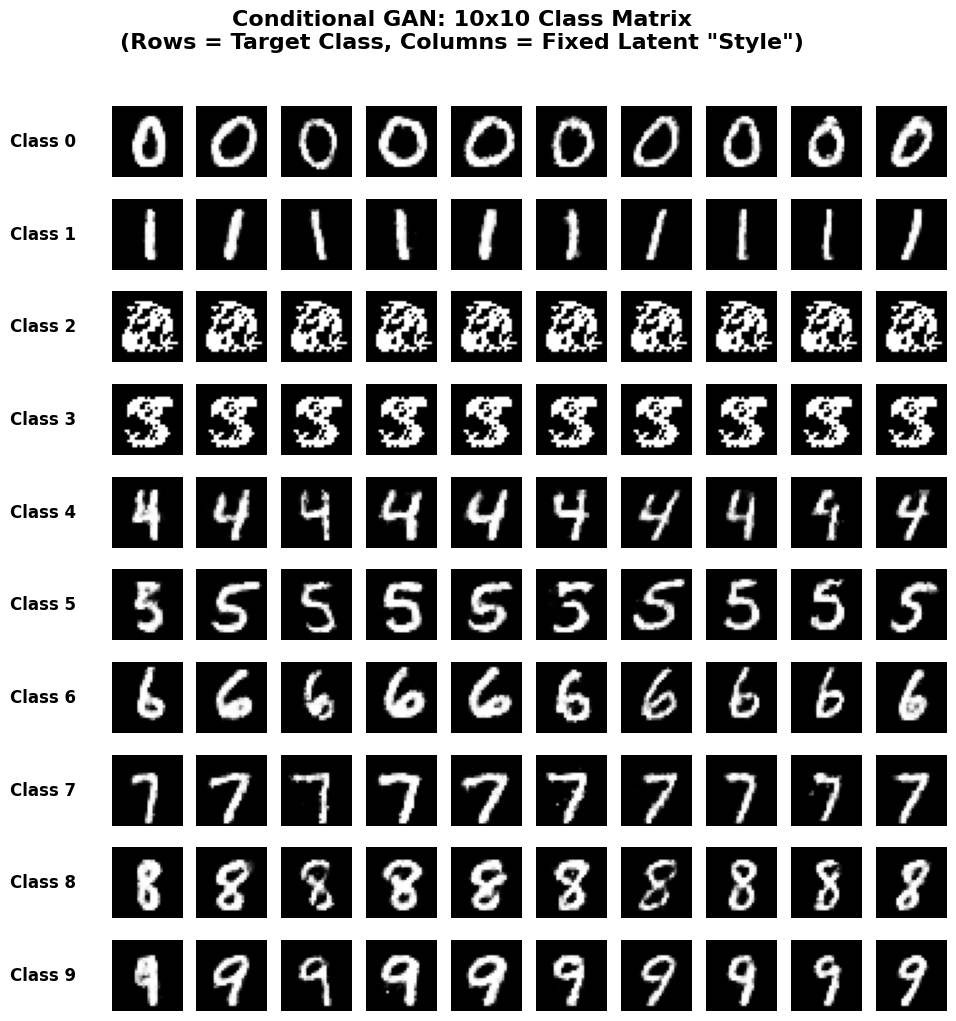

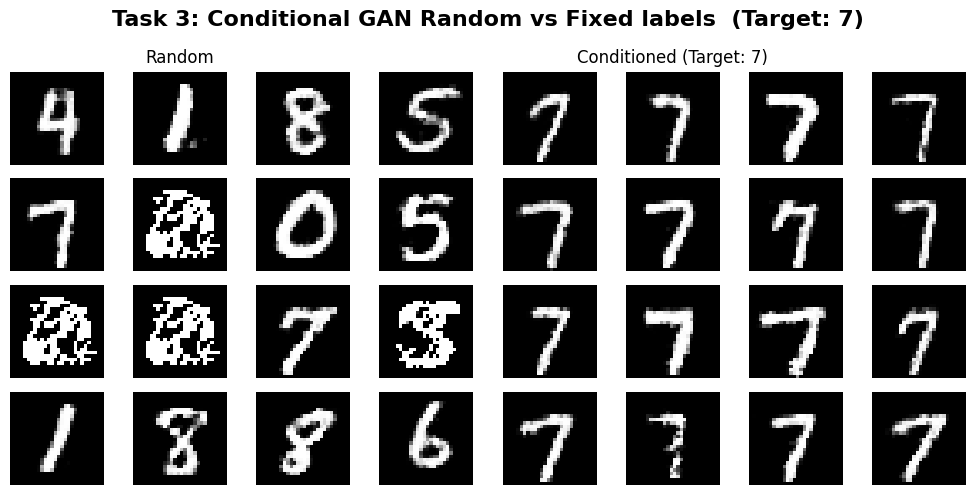

In [11]:
# Inference  
print("\n--- Generating Visualizations ---")
G.load_state_dict(torch.load('checkpoints/G_absolute_best.pth', weights_only=True))
G.eval()

num_classes = 10
samples_per_class = 10
fixed_z = torch.randn(samples_per_class, Z_dim).to(device)

fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(10, 10))
fig.suptitle('Conditional GAN: 10x10 Class Matrix\n(Rows = Target Class, Columns = Fixed Latent "Style")', fontsize=16, fontweight='bold', y=1.02)

with torch.no_grad():
    for target_class in range(num_classes):
        labels = torch.full((samples_per_class,), target_class, dtype=torch.long).to(device)
        generated_imgs = G(fixed_z, labels).cpu().numpy()

        for col in range(samples_per_class):
            ax = axes[target_class, col]
            ax.imshow(generated_imgs[col].reshape(28, 28), cmap='Greys_r')
            ax.axis('off')

            if col == 0:
                ax.text(-0.5, 0.5, f"Class {target_class}", transform=ax.transAxes, 
                        fontsize=12, fontweight='bold', va='center', ha='right')

plt.tight_layout()
plt.subplots_adjust(left=0.15) 
plt.show()

# SIDE-BY-SIDE COMPARISON
my_target = 7
with torch.no_grad():
    z_rand = torch.randn(16, Z_dim).to(device)
    l_rand = torch.randint(0, 10, (16,)).to(device)
    imgs_rand = G(z_rand, l_rand).cpu().numpy()
    
    z_cgan = torch.randn(16, Z_dim).to(device)
    l_cgan = torch.full((16,), my_target, dtype=torch.long).to(device)
    imgs_cgan = G(z_cgan, l_cgan).cpu().numpy()

fig, axes = plt.subplots(4, 8, figsize=(10, 5))
fig.suptitle(f'Task 3: Conditional GAN Random vs Fixed labels  (Target: {my_target})', fontsize=16, fontweight='bold')

for i in range(16):
    r, c = i // 4, i % 4
    axes[r, c].imshow(imgs_rand[i].reshape(28, 28), cmap='Greys_r')
    axes[r, c].axis('off')
    if r == 0 and c == 1: axes[r, c].set_title("Random", fontsize=12)

for i in range(16):
    r, c = i // 4, (i % 4) + 4
    axes[r, c].imshow(imgs_cgan[i].reshape(28, 28), cmap='Greys_r')
    axes[r, c].axis('off')
    if r == 0 and c == 5: axes[r, c].set_title(f"Conditioned (Target: {my_target})", fontsize=12)
plt.tight_layout()
plt.show()